# 성북구 아파트 실거래가 예측 - 머신러닝 모델링

**사용 모델:** 선형 회귀 / 랜덤 포레스트 / 그래디언트 부스팅 / 히스토그램 기반 그래디언트 부스팅

---
## 1. 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker 

from matplotlib import rcParams
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)

---
## 2. 데이터 로딩 및 기본 확인

In [2]:
df = pd.read_csv('final.csv', low_memory=False)

print('데이터 크기:', df.shape)
print()
print('결측치 현황 :')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('타겟 변수(거래금액_만원) 기본 통계:')
print(df['거래금액_만원'].describe())

데이터 크기: (11087, 71)

결측치 현황 :
도로명_key              2
난방방식                17
지상주차대수               9
지하주차대수               9
CCTV대수               9
홈네트워크               52
단지명_key_manual    9102
세대당_CCTV대수           9
dtype: int64

타겟 변수(거래금액_만원) 기본 통계:
count     11087.000000
mean      81930.785515
std       23043.572146
min        9800.000000
25%       67900.000000
50%       80000.000000
75%       95000.000000
max      210000.000000
Name: 거래금액_만원, dtype: float64


---
## 3. 변수 선택


In [3]:
df = pd.get_dummies(df, columns=['복도유형'], drop_first=True)

feature_cols = [
    '전용면적',
    '세대당_주차대수',
    '단지내_편의시설_유무',
    '건물나이',
    '최고층수',
    '복도유형_복도식',
    '복도유형_혼합식',
    '브랜드선호도_TOP20',
    '고도',
    '경사도',
    '역세권여부',
    '반경500m_버스정류장',
    '편의시설(병원_공원_소상공인)',
    '기준금리',
]

target_col = '거래금액_만원'

data = df[feature_cols + ['년도', '월', target_col]].copy()

print('분석 데이터 크기:', data.shape)
print('결측치:', data.isnull().sum().sum())


분석 데이터 크기: (11087, 17)
결측치: 0


---
## 4. 데이터 전처리 및 분할

In [4]:
train_mask = (data['년도'] < 2025) | ((data['년도'] == 2025) & (data['월'] <= 6))
train_data = data[train_mask]
test_data  = data[~train_mask]

train_input = train_data[feature_cols].values
test_input = test_data[feature_cols].values
train_target = train_data[target_col].values
test_target = test_data[target_col].values

print('훈련 세트 크기 (2021~2025.06):', train_input.shape)
print('테스트 세트 크기 (2025.07~):', test_input.shape)


훈련 세트 크기 (2021~2025.06): (9165, 14)
테스트 세트 크기 (2025.07~): (1922, 14)


In [5]:
# 표준화(선형 회귀에만 적용)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_input)
test_scaled = scaler.transform(test_input)

print('표준화 완료')
print('훈련 세트 평균(첫 5개 특성):', train_scaled[:, :5].mean(axis=0).round(4))
print('훈련 세트 표준편차(첫 5개 특성):', train_scaled[:, :5].std(axis=0).round(4))

표준화 완료
훈련 세트 평균(첫 5개 특성): [-0.  0.  0.  0.  0.]
훈련 세트 표준편차(첫 5개 특성): [1. 1. 1. 1. 1.]


---
## 5. 모델 학습 및 평가

In [6]:
results = {}
lr = LinearRegression()
lr.fit(train_scaled, train_target)
pred_lr = lr.predict(test_scaled)
results['선형 회귀'] = {
    '훈련 MAE'   : mean_absolute_error(train_target, lr.predict(train_scaled)),
    '테스트 MAE' : mean_absolute_error(test_target, pred_lr),
    '훈련 RMSE'  : np.sqrt(mean_squared_error(train_target, lr.predict(train_scaled))),
    '테스트 RMSE': np.sqrt(mean_squared_error(test_target, pred_lr)),
}

rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                            min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(train_input, train_target)
pred_rf = rf.predict(test_input)
results['랜덤 포레스트'] = {
    '훈련 MAE'   : mean_absolute_error(train_target, rf.predict(train_input)),
    '테스트 MAE' : mean_absolute_error(test_target, pred_rf),
    '훈련 RMSE'  : np.sqrt(mean_squared_error(train_target, rf.predict(train_input))),
    '테스트 RMSE': np.sqrt(mean_squared_error(test_target, pred_rf)),
}

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, subsample=0.8, random_state=42)
gb.fit(train_input, train_target)
pred_gb = gb.predict(test_input)
results['그래디언트 부스팅'] = {
    '훈련 MAE'   : mean_absolute_error(train_target, gb.predict(train_input)),
    '테스트 MAE' : mean_absolute_error(test_target, pred_gb),
    '훈련 RMSE'  : np.sqrt(mean_squared_error(train_target, gb.predict(train_input))),
    '테스트 RMSE': np.sqrt(mean_squared_error(test_target, pred_gb)),
}

hgb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                                     max_depth=6, random_state=42)
hgb.fit(train_input, train_target)
pred_hgb = hgb.predict(test_input)
results['히스토그램기반 그래디언트'] = {
    '훈련 MAE'   : mean_absolute_error(train_target, hgb.predict(train_input)),
    '테스트 MAE' : mean_absolute_error(test_target, pred_hgb),
    '훈련 RMSE'  : np.sqrt(mean_squared_error(train_target, hgb.predict(train_input))),
    '테스트 RMSE': np.sqrt(mean_squared_error(test_target, pred_hgb)),
}

result_df = pd.DataFrame(results).T
result_df.columns = ['Train MAE','Test MAE','Train RMSE','Test RMSE']
print(result_df.to_string(float_format='{:,.0f}'.format))


               Train MAE  Test MAE  Train RMSE  Test RMSE
선형 회귀              7,432    10,493      10,195     13,623
랜덤 포레스트            3,209     6,404       4,954      9,034
그래디언트 부스팅          3,262     5,632       4,806      7,783
히스토그램기반 그래디언트      3,130     5,331       4,730      7,394


In [7]:
tscv = TimeSeriesSplit(n_splits=5)

# 랜덤 포레스트 
rf_param = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [3, 6, 8, 10, 12],
    'min_samples_leaf' : [5, 10, 20, 30],
    'min_samples_split': [10, 20, 30],
    'max_features'     : ['sqrt', 'log2', 0.3],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param,
    n_iter=60, cv=tscv, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(train_input, train_target)
print('RF 최적 파라미터:', rf_search.best_params_)

# 그래디언트 부스팅
gb_param = {
    'n_estimators' : [300, 500, 700, 1000],
    'learning_rate': [0.005, 0.001, 0.01, 0.03, 0.05],
    'max_depth'        : [3, 4, 5],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'min_samples_leaf' : [10, 20, 30],
}
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param,
    n_iter=60, cv=tscv, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(train_input, train_target)
print('GB 최적 파라미터:', gb_search.best_params_)

# 4. 히스토그램 기반 GB 
hgb_param = {
    'max_iter'          : [500, 700, 1000, 1500],
    'learning_rate'     : [0.005, 0.001, 0.01, 0.03, 0.05],
    'max_depth'         : [4, 5, 6, 8],
    'min_samples_leaf'  : [20, 30, 50],
    'l2_regularization' : [0.0, 0.1, 0.5, 1.0],
    'max_bins'          : [128, 255],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=hgb_param,
    n_iter=60, cv=tscv, scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
hgb_search.fit(train_input, train_target)
print('HGB 최적 파라미터:', hgb_search.best_params_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
RF 최적 파라미터: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 10}
Fitting 5 folds for each of 60 candidates, totalling 300 fits
GB 최적 파라미터: {'subsample': 0.9, 'n_estimators': 1000, 'min_samples_leaf': 10, 'max_depth': 3, 'learning_rate': 0.05}
Fitting 5 folds for each of 60 candidates, totalling 300 fits
HGB 최적 파라미터: {'min_samples_leaf': 20, 'max_iter': 1000, 'max_depth': 4, 'max_bins': 255, 'learning_rate': 0.03, 'l2_regularization': 0.0}


In [8]:
tuned_results = {}

# 선형 회귀 
tuned_results['선형 회귀'] = {
    'Train MAE' : result_df.loc['선형 회귀', 'Train MAE'],
    'Test MAE'  : result_df.loc['선형 회귀', 'Test MAE'],
    'Train RMSE': result_df.loc['선형 회귀', 'Train RMSE'],
    'Test RMSE' : result_df.loc['선형 회귀', 'Test RMSE'],
}

# RF 튜닝
rf_best = rf_search.best_estimator_
tuned_results['랜덤 포레스트'] = {
    'Train MAE' : mean_absolute_error(train_target, rf_best.predict(train_input)),
    'Test MAE'  : mean_absolute_error(test_target,  rf_best.predict(test_input)),
    'Train RMSE': np.sqrt(mean_squared_error(train_target, rf_best.predict(train_input))),
    'Test RMSE' : np.sqrt(mean_squared_error(test_target,  rf_best.predict(test_input))),
}

# GB 튜닝
gb_best = gb_search.best_estimator_
tuned_results['그래디언트 부스팅'] = {
    'Train MAE' : mean_absolute_error(train_target, gb_best.predict(train_input)),
    'Test MAE'  : mean_absolute_error(test_target,  gb_best.predict(test_input)),
    'Train RMSE': np.sqrt(mean_squared_error(train_target, gb_best.predict(train_input))),
    'Test RMSE' : np.sqrt(mean_squared_error(test_target,  gb_best.predict(test_input))),
}

# HGB 튜닝
hgb_best = hgb_search.best_estimator_
tuned_results['히스토그램기반 그래디언트'] = {
    'Train MAE' : mean_absolute_error(train_target, hgb_best.predict(train_input)),
    'Test MAE'  : mean_absolute_error(test_target,  hgb_best.predict(test_input)),
    'Train RMSE': np.sqrt(mean_squared_error(train_target, hgb_best.predict(train_input))),
    'Test RMSE' : np.sqrt(mean_squared_error(test_target,  hgb_best.predict(test_input))),
}

tuned_df = pd.DataFrame(tuned_results).T

print('=== 튜닝 전 ===')
print(result_df.to_string(float_format='{:,.0f}'.format))
print()
print('=== 튜닝 후 ===')
print(tuned_df.to_string(float_format='{:,.0f}'.format))


=== 튜닝 전 ===
               Train MAE  Test MAE  Train RMSE  Test RMSE
선형 회귀              7,432    10,493      10,195     13,623
랜덤 포레스트            3,209     6,404       4,954      9,034
그래디언트 부스팅          3,262     5,632       4,806      7,783
히스토그램기반 그래디언트      3,130     5,331       4,730      7,394

=== 튜닝 후 ===
               Train MAE  Test MAE  Train RMSE  Test RMSE
선형 회귀              7,432    10,493      10,195     13,623
랜덤 포레스트            3,993     6,555       5,882      8,786
그래디언트 부스팅          3,519     5,369       5,192      7,328
히스토그램기반 그래디언트      3,446     5,339       5,137      7,392


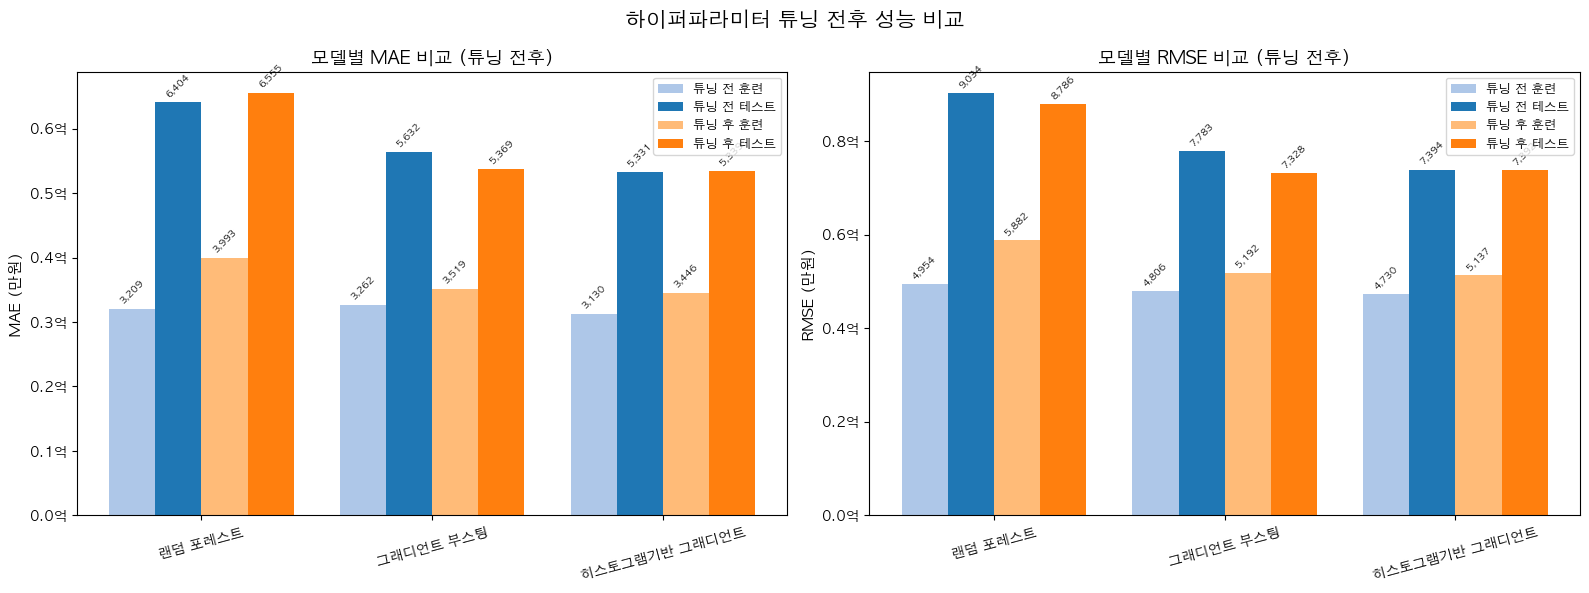

In [12]:
model_names = [m for m in tuned_results.keys() if m != '선형 회귀']
x     = np.arange(len(model_names))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, m_train, m_test, title, ylabel in [
    (axes[0], 'Train MAE',  'Test MAE',  '모델별 MAE 비교 (튜닝 전후)', 'MAE (만원)'),
    (axes[1], 'Train RMSE', 'Test RMSE', '모델별 RMSE 비교 (튜닝 전후)', 'RMSE (만원)'),
]:
    bt = [result_df.loc[m, m_train] for m in model_names]
    bv = [result_df.loc[m, m_test]  for m in model_names]
    at = [tuned_df.loc[m, m_train]  for m in model_names]
    av = [tuned_df.loc[m, m_test]   for m in model_names]

    b1 = ax.bar(x - width*1.5, bt, width, label='튜닝 전 훈련',  color='#aec7e8')
    b2 = ax.bar(x - width*0.5, bv, width, label='튜닝 전 테스트', color='#1f77b4')
    b3 = ax.bar(x + width*0.5, at, width, label='튜닝 후 훈련',  color='#ffbb78')
    b4 = ax.bar(x + width*1.5, av, width, label='튜닝 후 테스트', color='#ff7f0e')

    for bars, vals in [(b1,bt),(b2,bv),(b3,at),(b4,av)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{val:,.0f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/10000:.1f}억'))
    ax.legend(fontsize=9)

plt.suptitle('하이퍼파라미터 튜닝 전후 성능 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


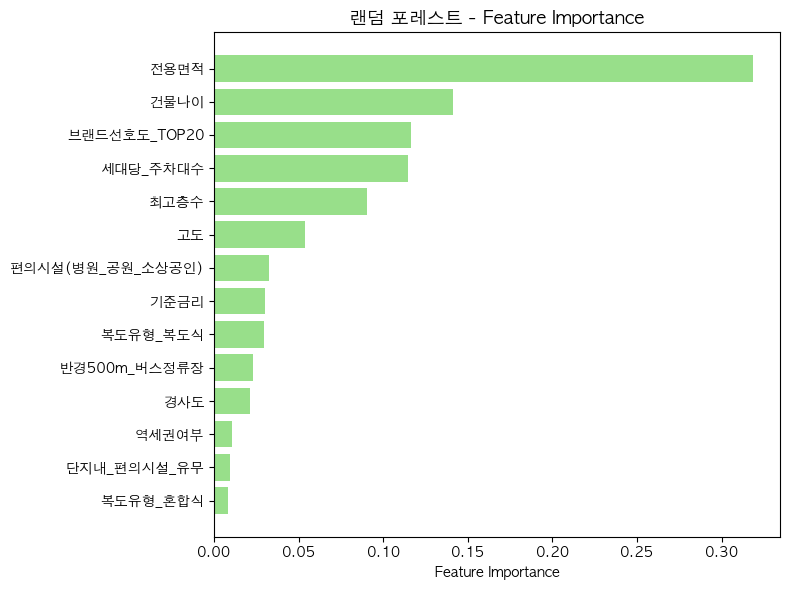

In [10]:
imp = rf_best.feature_importances_   # 또는 gb_best
idx = np.argsort(imp)

plt.figure(figsize=(8, 6))
plt.barh([feature_cols[i] for i in idx], imp[idx], color='#98df8a')
plt.xlabel('Feature Importance')
plt.title('랜덤 포레스트 - Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
